In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;
using JJDFTX: kinetic_energy
interpolate = pyimport("scipy.interpolate")

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


PyObject <module 'scipy.interpolate' from '/home/gridsan/aligho/.local/lib/python3.8/site-packages/scipy/interpolate/__init__.py'>

In [3]:
kpoints = bandstructkpoints2q(interpolate=5);
lattice_vectors = loadlattice("wannier-41.out");

In [5]:
charge = -0.5
HwannierUp, cell_mapUp = hwannier("wannier-$(charge)Up"), np.loadtxt("wannier-$(charge)Up.map.txt");
HwannierDn, cell_mapDn = hwannier("wannier-$(charge)Dn"), np.loadtxt("wannier-$(charge)Dn.map.txt");

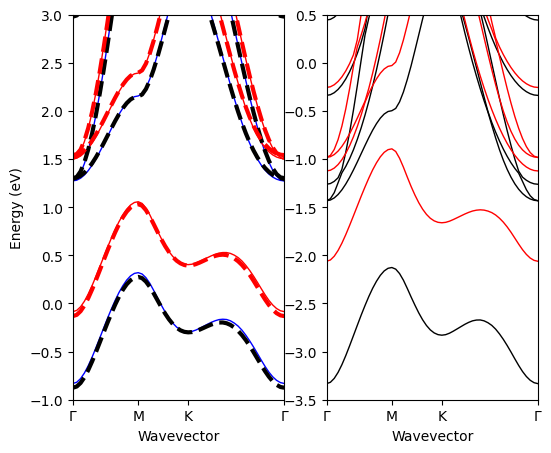

(-3.5, 0.5)

In [6]:
figure(figsize=(6, 5))
subplot(1, 2, 1)
plot_bands("../BN22BCbands--0.5.eigenvals", spin=2, linewidth=1)
plot_bands(HwannierUp, cell_mapUp, color="black", linestyle="dashed", linewidth=3)
plot_bands(HwannierDn, cell_mapDn, color="red", linestyle="dashed", linewidth=3)
ylim(-1, 3)
subplot(1, 2, 2)
plot_bands("../../BN22BC.bands.eigenvals", color_up="black", color_dn="red", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
ylabel("")
ylim(-3.5, 0.5)

In [55]:
# Find Chemical Potentials

In [135]:
histogram_width = 100
mesh = 20
num_blocks = 100
#for charge in [-0.8, -0.6, -0.4]
for charge in [-0.5]
    HwannierUp, cell_mapUp = hwannier("wannier-$(charge)Up"), np.loadtxt("wannier-$(charge)Up.map.txt");
    HwannierDn, cell_mapDn = hwannier("wannier-$(charge)Dn"), np.loadtxt("wannier-$(charge)Dn.map.txt");
    es_up, ds_up = density_of_states(HwannierUp, cell_mapUp, histogram_width=histogram_width, degeneracy=1, num_blocks=num_blocks, mesh=mesh, 
        monte_carlo=true)
    es_dn, ds_dn = density_of_states(HwannierDn, cell_mapDn, histogram_width=histogram_width, degeneracy=1,  num_blocks=num_blocks, mesh=mesh, 
        monte_carlo=true)
    es1_up, ns_up =  find_chemical_potential(es_up, ds_up)
    es1_dn, ns_dn =  find_chemical_potential(es_dn, ds_dn);
    f_up = interpolate.interp1d(es1_up, ns_up)
    f_dn = interpolate.interp1d(es1_dn, ns_dn)
    e_range = collect(-10:0.01:10)
    n_total = first.(f_up.(e_range)) + first.(f_dn.(e_range));
    println("DOS at charge $(charge) is $(e_range[argmin(abs.(n_total .- 33 .- charge))])"); flush(stdout)
end

DOS at charge -0.5 is -0.17


In [20]:
energies = collect(range(0, 100, length=10000));
all_epsilons = Matrix{Float64}[]
for charge in [-0.8, -0.6, -0.4, -0.5]
    println("Charge: $(charge)"); flush(stdout)
    epsilons_default = zeros(50, 200);
    for (i, k) in enumerate(kpoints[1:50])
        i == 1 && continue
        polarizations = parse.(Float64, readlines("Plasmon-$(charge).out-$i"))
        for (j, ω) in enumerate(range(0.05, 1.5, length=200))
            epsilons_default[i, j] = abs(ϵ(k, lattice_vectors, ω, energies, smooth(polarizations, win_len=1), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
        end
    end
    push!(all_epsilons, epsilons_default)
end

Charge: -0.8
Charge: -0.6
Charge: -0.4
Charge: -0.5


In [27]:
#landau_lower_alt = zeros(50);
#landau_upper_alt = zeros(50);
all_plasmons = Vector{Float64}[]
qs_all = []
for (i, charge) in enumerate([-0.8, -0.6, -0.4, -0.5])
    smoothed_epsilon = smooth(all_epsilons[i], win_len=10)
    plasmon_default = [range(0.05, 1.5, length=200)[argmin(x)] for x in eachrow(log.(abs.(smoothed_epsilon[2:50, :])))];
    plasmon_default = [0, plasmon_default...]
    qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_default)
    confinements[1] = 0
    plasmon_default = smooth(plasmon_default, win_len=10)
    confinements = smooth(confinements, win_len=1);
    plasmon_default[1] = 0
    confinements[1] = 0;
    push!(all_plasmons, plasmon_default)
    push!(qs_all, qs)
end

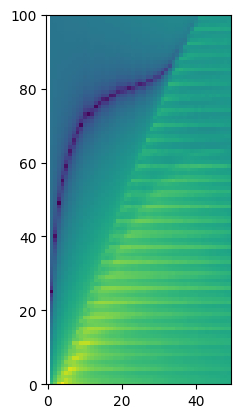

(0.0, 100.0)

In [28]:
imshow(transpose(log.(abs.(all_epsilons[3])))[:, 1:50], origin="lower")
ylim(0, 100)

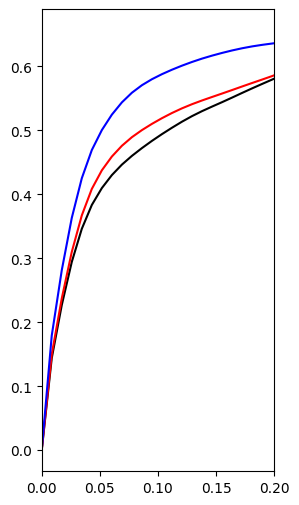

(0.0, 0.2)

In [32]:
q_range = 1:30
figure(figsize=(3, 6))
plot(qs_all[1][q_range], all_plasmons[1][q_range], color = "black")
plot(qs_all[1][q_range], all_plasmons[2][q_range], color = "red")
plot(qs_all[1][q_range], all_plasmons[3][q_range], color = "blue")

xlim(0, 0.2)
#ylim(0, 0.7)

In [35]:
np.savetxt("Plasmon.txt", hcat(qs_all[1][q_range], all_plasmons[1][q_range], all_plasmons[2][q_range], all_plasmons[3][q_range]), 
        header="-0.8, -0.6, -0.4")

In [69]:
for (i, k) in enumerate(kpoints[1:50])
    polarizations = parse.(Float64, readlines("Plasmon-$(charge).out-$i"))
    non_zero_impols = energies[findall(.!iszero.(polarizations))]
    landau_lower_alt[i] = maximum([filter(x-> x < plasmon_default[i], non_zero_impols)..., 0])
    landau_upper_alt[i] = minimum(filter(x-> x > plasmon_default[i], non_zero_impols))
end

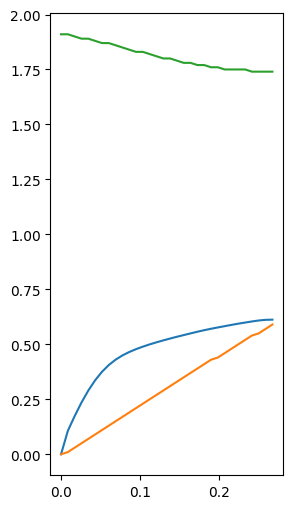

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7efddfa3b0d0>

In [76]:
figure(figsize=(3, 6))
q_range = 1:32
plot(qs[q_range], plasmon_default[q_range, :])
plot(qs[q_range], landau_lower_alt[q_range])
plot(qs[q_range], landau_upper_alt[q_range])

In [7]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/BN22BC/Doping/wannier"